# Normative Modelling: Hierarchical Bayesian Regression with SHASH likelihood

Welcome to this tutorial notebook that will go through the fitting and evaluation of Normative models with a Hierarchical Bayesian Regression model using a SHASH likelihood. 

Let's jump right in.

### Imports

In [1]:
import warnings
import logging
import os
import sys


import pandas as pd
import matplotlib.pyplot as plt
from pcntoolkit import (
    HBR,
    BsplineBasisFunction,
    NormativeModel,
    NormData,
    #load_fcon1000,
    SHASHbLikelihood,
    make_prior,
    plot_centiles,
    plot_qq,
    plot_ridge,
    Runner
)

import numpy as np
import pcntoolkit.util.output
import seaborn as sns

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")

pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'
pcntoolkit.util.output.Output.set_show_messages(False)

## Load data

First we convert the data into a NormData Object

In [2]:
data_out_dir = '/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/DATA/DES'

#train = pd.read_pickle(os.path.join(data_in_dir,"train_SC_demented_adults_ADNI.pkl"))
#test = pd.read_pickle(os.path.join(data_in_dir,"test_SC_demented_adults_ADNI.pkl"))

#train = pd.read_pickle(os.path.join(data_in_dir,"train_DK_demented_adults_ADNI.pkl"))
#test = pd.read_pickle(os.path.join(data_in_dir,"test_DK_demented_adults_ADNI.pkl"))

#train = pd.read_pickle(os.path.join(data_in_dir,"train_DES_demented_adults_ADNI.pkl"))
#test = pd.read_pickle(os.path.join(data_in_dir,"test_DES_demented_adults_ADNI.pkl"))

#train = pd.read_pickle(os.path.join(data_in_dir,"train_retrain_full_models_DES_adults_ADNI.pkl"))
#test = pd.read_pickle(os.path.join(data_in_dir,"train_retrain_full_models_DES_adults_ADNI.pkl"))

#data = pd.read_csv("/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/FS_DATA/fs_stats-0.2.1/PPMI.csv")
train = pd.read_csv("/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/FS_DATA/fs_stats-0.2.1/PPMI_HC_DES.csv")
test = pd.read_csv("/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/FS_DATA/fs_stats-0.2.1/PPMI_clinical_DES.csv")

features_to_model = list(train.columns)
features_to_model


['Unnamed: 0',
 'visit_id',
 'participant_id',
 'lh_G_and_S_frontomargin',
 'lh_G_and_S_occipital_inf',
 'lh_G_and_S_paracentral',
 'lh_G_and_S_subcentral',
 'lh_G_and_S_transv_frontopol',
 'lh_G_and_S_cingul-Ant',
 'lh_G_and_S_cingul-Mid-Ant',
 'lh_G_and_S_cingul-Mid-Post',
 'lh_G_cingul-Post-dorsal',
 'lh_G_cingul-Post-ventral',
 'lh_G_cuneus',
 'lh_G_front_inf-Opercular',
 'lh_G_front_inf-Orbital',
 'lh_G_front_inf-Triangul',
 'lh_G_front_middle',
 'lh_G_front_sup',
 'lh_G_Ins_lg_and_S_cent_ins',
 'lh_G_insular_short',
 'lh_G_occipital_middle',
 'lh_G_occipital_sup',
 'lh_G_oc-temp_lat-fusifor',
 'lh_G_oc-temp_med-Lingual',
 'lh_G_oc-temp_med-Parahip',
 'lh_G_orbital',
 'lh_G_pariet_inf-Angular',
 'lh_G_pariet_inf-Supramar',
 'lh_G_parietal_sup',
 'lh_G_postcentral',
 'lh_G_precentral',
 'lh_G_precuneus',
 'lh_G_rectus',
 'lh_G_subcallosal',
 'lh_G_temp_sup-G_T_transv',
 'lh_G_temp_sup-Lateral',
 'lh_G_temp_sup-Plan_polar',
 'lh_G_temp_sup-Plan_tempo',
 'lh_G_temporal_inf',
 'lh_G_t

In [3]:
#plotdir = os.path.join(out_dir, "plots")# Select only a few features
covariates = ["age"]
batch_effects = ["sex", "site_id2"]

features_to_model = [
 'lh_G_and_S_frontomargin',
 'lh_G_and_S_occipital_inf',
 'lh_G_and_S_paracentral',
 'lh_G_and_S_subcentral',
 'lh_G_and_S_transv_frontopol',
 'lh_G_and_S_cingul-Ant',
 'lh_G_and_S_cingul-Mid-Ant',
 'lh_G_and_S_cingul-Mid-Post',
 'lh_G_cingul-Post-dorsal',
 'lh_G_cingul-Post-ventral',
 'lh_G_cuneus',
 'lh_G_front_inf-Opercular',
 'lh_G_front_inf-Orbital',
 'lh_G_front_inf-Triangul',
 'lh_G_front_middle',
 'lh_G_front_sup',
 'lh_G_Ins_lg_and_S_cent_ins',
 'lh_G_insular_short',
 'lh_G_occipital_middle',
 'lh_G_occipital_sup',
 'lh_G_oc-temp_lat-fusifor',
 'lh_G_oc-temp_med-Lingual',
 'lh_G_oc-temp_med-Parahip',
 'lh_G_orbital',
 'lh_G_pariet_inf-Angular',
 'lh_G_pariet_inf-Supramar',
 'lh_G_parietal_sup',
 'lh_G_postcentral',
 'lh_G_precentral',
 'lh_G_precuneus',
 'lh_G_rectus',
 'lh_G_subcallosal',
 'lh_G_temp_sup-G_T_transv',
 'lh_G_temp_sup-Lateral',
 'lh_G_temp_sup-Plan_polar',
 'lh_G_temp_sup-Plan_tempo',
 'lh_G_temporal_inf',
 'lh_G_temporal_middle',
 'lh_Lat_Fis-ant-Horizont',
 'lh_Lat_Fis-ant-Vertical',
 'lh_Lat_Fis-post',
 'lh_Pole_occipital',
 'lh_Pole_temporal',
 'lh_S_calcarine',
 'lh_S_central',
 'lh_S_cingul-Marginalis',
 'lh_S_circular_insula_ant',
 'lh_S_circular_insula_inf',
 'lh_S_circular_insula_sup',
 'lh_S_collat_transv_ant',
 'lh_S_collat_transv_post',
 'lh_S_front_inf',
 'lh_S_front_middle',
 'lh_S_front_sup',
 'lh_S_interm_prim-Jensen',
 'lh_S_intrapariet_and_P_trans',
 'lh_S_oc_middle_and_Lunatus',
 'lh_S_oc_sup_and_transversal',
 'lh_S_occipital_ant',
 'lh_S_oc-temp_lat',
 'lh_S_oc-temp_med_and_Lingual',
 'lh_S_orbital_lateral',
 'lh_S_orbital_med-olfact',
 'lh_S_orbital-H_Shaped',
 'lh_S_parieto_occipital',
 'lh_S_pericallosal',
 'lh_S_postcentral',
 'lh_S_precentral-inf-part',
 'lh_S_precentral-sup-part',
 'lh_S_suborbital',
 'lh_S_subparietal',
 'lh_S_temporal_inf',
 'lh_S_temporal_sup',
 'lh_S_temporal_transverse',
 'rh_G_and_S_frontomargin',
 'rh_G_and_S_occipital_inf',
 'rh_G_and_S_paracentral',
 'rh_G_and_S_subcentral',
 'rh_G_and_S_transv_frontopol',
 'rh_G_and_S_cingul-Ant',
 'rh_G_and_S_cingul-Mid-Ant',
 'rh_G_and_S_cingul-Mid-Post',
 'rh_G_cingul-Post-dorsal',
 'rh_G_cingul-Post-ventral',
 'rh_G_cuneus',
 'rh_G_front_inf-Opercular',
 'rh_G_front_inf-Orbital',
 'rh_G_front_inf-Triangul',
 'rh_G_front_middle',
 'rh_G_front_sup',
 'rh_G_Ins_lg_and_S_cent_ins',
 'rh_G_insular_short',
 'rh_G_occipital_middle',
 'rh_G_occipital_sup',
 'rh_G_oc-temp_lat-fusifor',
 'rh_G_oc-temp_med-Lingual',
 'rh_G_oc-temp_med-Parahip',
 'rh_G_orbital',
 'rh_G_pariet_inf-Angular',
 'rh_G_pariet_inf-Supramar',
 'rh_G_parietal_sup',
 'rh_G_postcentral',
 'rh_G_precentral',
 'rh_G_precuneus',
 'rh_G_rectus',
 'rh_G_subcallosal',
 'rh_G_temp_sup-G_T_transv',
 'rh_G_temp_sup-Lateral',
 'rh_G_temp_sup-Plan_polar',
 'rh_G_temp_sup-Plan_tempo',
 'rh_G_temporal_inf',
 'rh_G_temporal_middle',
 'rh_Lat_Fis-ant-Horizont',
 'rh_Lat_Fis-ant-Vertical',
 'rh_Lat_Fis-post',
 'rh_Pole_occipital',
 'rh_Pole_temporal',
 'rh_S_calcarine',
 'rh_S_central',
 'rh_S_cingul-Marginalis',
 'rh_S_circular_insula_ant',
 'rh_S_circular_insula_inf',
 'rh_S_circular_insula_sup',
 'rh_S_collat_transv_ant',
 'rh_S_collat_transv_post',
 'rh_S_front_inf',
 'rh_S_front_middle',
 'rh_S_front_sup',
 'rh_S_interm_prim-Jensen',
 'rh_S_intrapariet_and_P_trans',
 'rh_S_oc_middle_and_Lunatus',
 'rh_S_oc_sup_and_transversal',
 'rh_S_occipital_ant',
 'rh_S_oc-temp_lat',
 'rh_S_oc-temp_med_and_Lingual',
 'rh_S_orbital_lateral',
 'rh_S_orbital_med-olfact',
 'rh_S_orbital-H_Shaped',
 'rh_S_parieto_occipital',
 'rh_S_pericallosal',
 'rh_S_postcentral',
 'rh_S_precentral-inf-part',
 'rh_S_precentral-sup-part',
 'rh_S_suborbital',
 'rh_S_subparietal',
 'rh_S_temporal_inf',
 'rh_S_temporal_sup',
 'rh_S_temporal_transverse',
 'Mean_Thickness',
 'Median_Thickness'
]

norm_train = NormData.from_dataframe(
    name="train", dataframe=train, covariates=covariates, batch_effects=batch_effects, response_vars=features_to_model
)
norm_test = NormData.from_dataframe(
    name="test", dataframe=test, covariates=covariates, batch_effects=batch_effects, response_vars=features_to_model
)



In [4]:
norm_train

<xarray.NormData> Size: 388kB
Dimensions:            (observations: 297, response_vars: 150, covariates: 1,
                        batch_effect_dims: 2)
Coordinates:
  * observations       (observations) int64 2kB 0 1 2 3 4 ... 293 294 295 296
  * response_vars      (response_vars) <U28 17kB 'lh_G_and_S_frontomargin' .....
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U8 64B 'sex' 'site_id2'
Data variables:
    subject_ids        (observations) int64 2kB 0 1 2 3 4 ... 293 294 295 296
    Y                  (observations, response_vars) float64 356kB 2.226 ... ...
    X                  (observations, covariates) float64 2kB 63.2 73.8 ... 70.6
    batch_effects      (observations, batch_effect_dims) <U3 7kB 'F' ... '160'
Attributes:
    real_ids:                       False
    is_scaled:                      False
    name:                           train
    unique_batch_effects:           {np.str_('sex'): [np.str_('F'), np.str_('...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'mean': np.float64(60.7...
    batch_effect_covariate_ranges:  {np.str_('sex'): {np.str_('F'): {np.str_(...

In [5]:
#model_path = '/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/CODE_new/models_public/save_dir_DES_all_regions_full_datasets/'

In [6]:
model_path ='/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/CODE_new/resources/hbr_SHASH/save_dir_DES_ADNI_demented_revision/'

In [7]:
central_model = NormativeModel.load(model_path)

In [8]:
central_model

In [9]:
batch_effects = list(central_model.unique_batch_effects.keys())
covariates = central_model.covariates
response_vars = central_model.response_vars

In [10]:
print(batch_effects)
print(train[batch_effects].to_numpy())
print(response_vars)

['sex', 'site_id2']
[['F' 160]
 ['M' 160]
 ['F' 160]
 ['M' 160]
 ['F' 160]
 ['M' 160]
 ['M' 160]
 ['M' 160]
 ['F' 160]
 ['F' 160]
 ['M' 160]
 ['F' 160]
 ['M' 160]
 ['F' 160]
 ['M' 160]
 ['M' 160]
 ['M' 160]
 ['M' 160]
 ['F' 160]
 ['M' 160]
 ['F' 160]
 ['F' 160]
 ['M' 160]
 ['F' 160]
 ['F' 160]
 ['M' 160]
 ['M' 160]
 ['M' 160]
 ['M' 160]
 ['F' 160]
 ['F' 160]
 ['F' 160]
 ['F' 160]
 ['F' 160]
 ['M' 160]
 ['M' 160]
 ['F' 160]
 ['M' 160]
 ['M' 160]
 ['M' 160]
 ['M' 160]
 ['F' 160]
 ['M' 160]
 ['M' 160]
 ['F' 160]
 ['F' 160]
 ['F' 160]
 ['M' 160]
 ['F' 160]
 ['M' 160]
 ['F' 160]
 ['M' 160]
 ['M' 160]
 ['M' 160]
 ['F' 160]
 ['F' 160]
 ['F' 160]
 ['M' 160]
 ['F' 160]
 ['M' 160]
 ['M' 160]
 ['M' 160]
 ['M' 160]
 ['F' 160]
 ['F' 160]
 ['F' 160]
 ['M' 160]
 ['M' 160]
 ['M' 160]
 ['F' 160]
 ['M' 160]
 ['M' 160]
 ['F' 160]
 ['M' 160]
 ['M' 160]
 ['M' 160]
 ['M' 160]
 ['F' 160]
 ['F' 160]
 ['F' 160]
 ['F' 160]
 ['M' 160]
 ['M' 160]
 ['F' 160]
 ['M' 160]
 ['M' 160]
 ['M' 160]
 ['M' 160]
 ['M' 160]
 

In [11]:
response_vars = [v for v in response_vars if v in train.columns]

# Some response variables in the pretrained model may not have been 
# successfully fitted during training.
# We exclude them here to avoid errors during transfer.
fitted_response_vars = [
    rv for rv in response_vars
    if rv in central_model.response_vars and central_model[rv].is_fitted
]

skipped_response_vars = [
    rv for rv in response_vars
    if rv not in fitted_response_vars
]
print(f"Using {len(fitted_response_vars)} fitted response variables")
print("Skipped (not fitted):", skipped_response_vars)

Using 150 fitted response variables
Skipped (not fitted): []


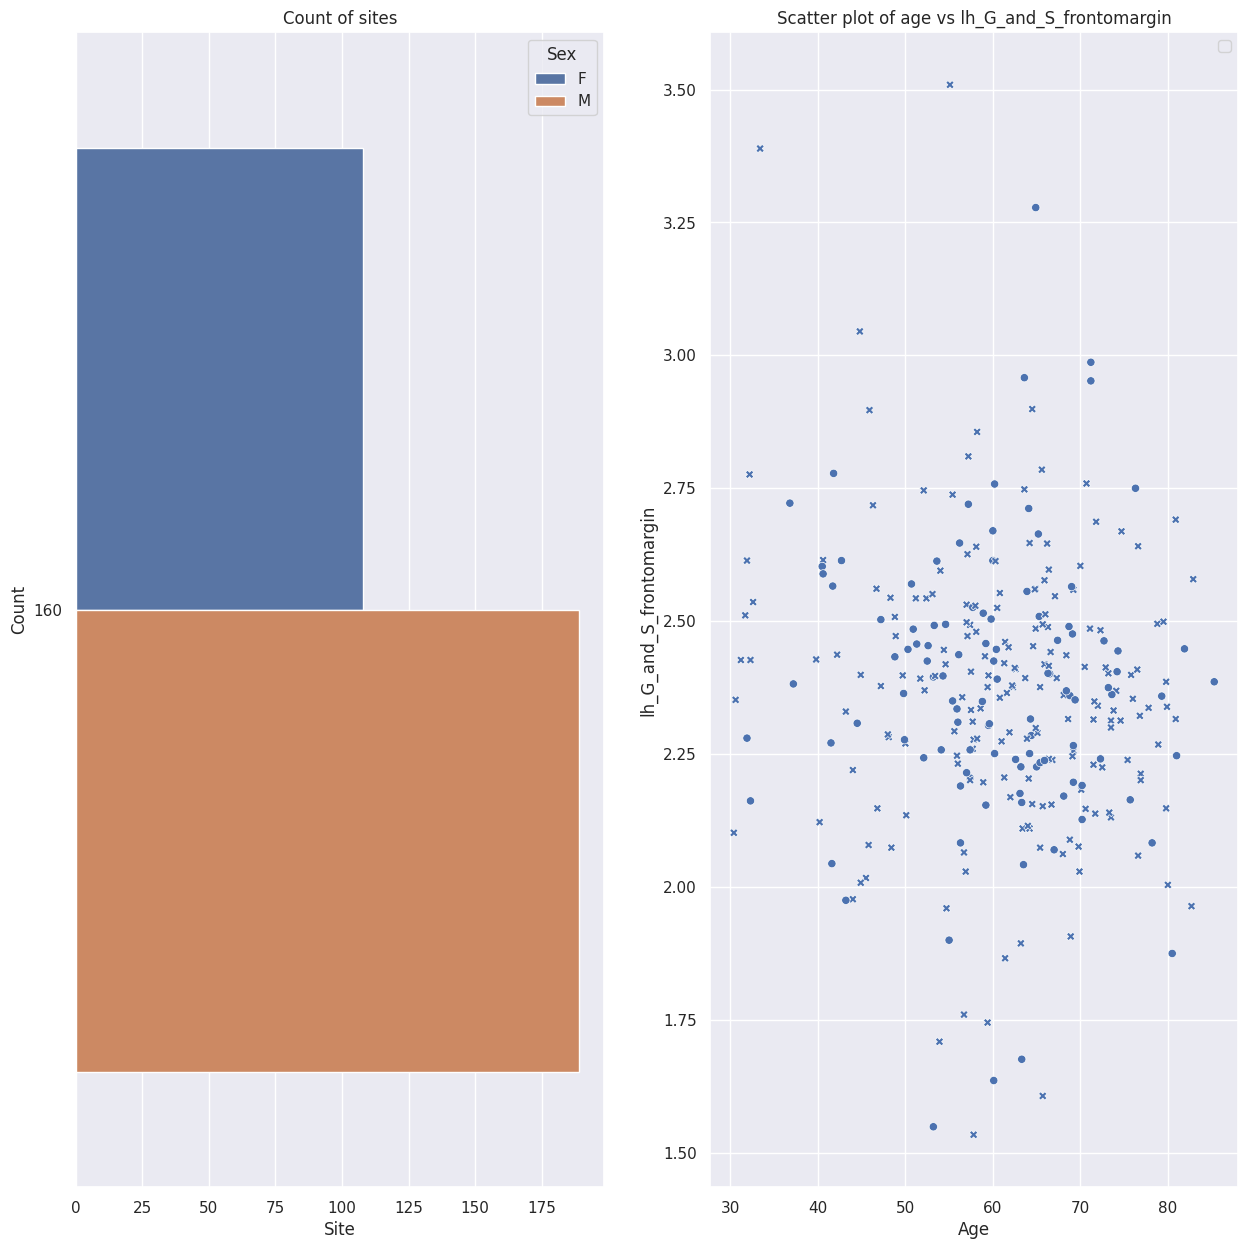

In [12]:
# Visualize the data
feature_to_plot = features_to_model[0]
df = norm_train.to_dataframe()
fig, ax = plt.subplots(1, 2, figsize=(15, 15))

sns.countplot(data=df, y=("batch_effects", "site_id2"), hue=("batch_effects","sex"), ax=ax[0], orient="h")
ax[0].legend(title="Sex")
ax[0].set_title("Count of sites")
ax[0].set_xlabel("Site")
ax[0].set_ylabel("Count")


sns.scatterplot(
    data=df,
    x=("X", "age"),
    y=("Y", feature_to_plot),
    hue=("batch_effects", "site_id2"),
    style=("batch_effects","sex"),
    ax=ax[1],
)
ax[1].legend([], [])
ax[1].set_title(f"Scatter plot of age vs {feature_to_plot}")
ax[1].set_xlabel("Age")
ax[1].set_ylabel(feature_to_plot)

plt.show()

In [13]:
#transferred_model = central_model.transfer_predict(norm_train, norm_test, save_dir=data_in_dir)

In [14]:
!pwd


/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/CODE_new


In [15]:
conda_env_path = os.path.join(os.path.dirname(os.path.dirname(sys.executable)))

In [16]:
runner = Runner(
    cross_validate=False,
    parallelize=True,
    environment=conda_env_path,
    job_type="slurm",  # or "torque" if you are on a torque cluster
    n_batches=150,
    time_limit="72:00:00",
    n_cores = 8,
    memory = '56gb',
    log_dir="resources/runner_output/log_dir",
    temp_dir="resources/runner_output/temp_dir",
)

In [17]:
runner.transfer_predict(central_model,norm_train, norm_test, save_dir="/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/CODE_new/transfer_models/DES2/")


---------------------------------------------------------
              PCNtoolkit Job Status Monitor ®
---------------------------------------------------------
Task ID: transfer_predict_train__2026-08-14_14:19:04_252.296387
---------------------------------------------------------
Job ID      Name          State      Time      Nodes
---------------------------------------------------------

54770009    transfer_predict_train__2026-08-14_14:19:04_252.296387_job_0 COMPLETED                          
54770010    transfer_predict_train__2026-08-14_14:19:04_252.296387_job_1 COMPLETED                          
54770011    transfer_predict_train__2026-08-14_14:19:04_252.296387_job_2 COMPLETED                          
54770012    transfer_predict_train__2026-08-14_14:19:04_252.296387_job_3 COMPLETED                          
54770013    transfer_predict_train__2026-08-14_14:19:04_252.296387_job_4 COMPLETED                          
54770014    transfer_predict_train__2026-08-14_14:19:04_25

AlignmentError: cannot reindex or align along dimension 'response_vars' because of conflicting dimension sizes: {50, 150} (note: an index is found along that dimension with size=150)

In [14]:
from pcntoolkit.util.runner import Runner

# 1. Restore the runner from its state JSON (path to the FILE, not the dir)
runner = Runner.load_from_state("/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/CODE_new/transfer_models/DES/.json")

# 2. (optional but recommended) see what it thinks failed, and why
running, failed, finished = runner.check_jobs_status()
print(failed)          # {job_name: error_message}


Help on function re_submit_failed_jobs in module pcntoolkit.util.runner:

re_submit_failed_jobs(self, observe: bool = True) -> None



In [7]:
import copy
w_dir = "/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/CODE_new/PCNtoolkit/examples/resources/hbr_SHASH/save_dir_new/"
region = "Left-Lateral-Ventricle"
model= NormativeModel.load(os.path.join(w_dir)) # i'm using batches of variabels but your just grab the NormativeModel.json object here wherever it is for oyu
response_var = f'{region}'



#select a single var to avoid plotting the whole batch
def select_for_response_var(model: NormativeModel, data: NormData, response_var: str):
    if response_var not in model.regression_models:
        raise ValueError(f"Response variable '{response_var}' not in model.")
    new_model = copy.deepcopy(model)
    new_model.response_vars = [response_var]
    new_model.regression_models = {response_var: new_model.regression_models[response_var]}
    new_model.outscalers = {response_var: new_model.outscalers[response_var]} if new_model.outscalers else {}
    ## there might be some extra attributes to grab here if you're using HBR though, i haven't used it
    new_data = data.sel({"response_vars": response_var}, drop=False)
    new_data["Y"] = new_data.Y.expand_dims("response_vars", axis=-1) #preserves 1d of norm_data.Y because single voxel, otherwise plot will error
    new_data = new_data.assign_coords(response_vars=[response_var])
    return new_model, new_data
    
modelvox, testvox = select_for_response_var(model, norm_test, region) 


In [3]:
from pcntoolkit import NormativeModel

model = NormativeModel.load(path="/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/CODE_new/transfer_models/old/DES/")


## Plot the results

The PCNtoolkit offers are a number of different plotting functions:
1. plot_centiles: Plot the predicted centiles for a model
2. plot_qq: Plot the QQ-plot of the predicted Z-scores
3. plot_ridge: Plot density plots of the predicted Z-scores

Let's start with the centiles.

In [13]:
model.batch_effect_covariate_ranges

{'sex': {'F': {'age': {'mean': 60.025, 'min': 31.9, 'max': 85.3}},
  'M': {'age': {'mean': 61.12010582010583, 'min': 30.4, 'max': 82.9}}},
 'site_id2': {'160': {'age': {'mean': 60.72188552188551,
    'min': 30.4,
    'max': 85.3}}}}

In [11]:
vars(model).keys() 

dict_keys(['savemodel', 'evaluate_model', 'saveresults', 'saveplots', '_save_dir', 'inscaler', 'outscaler', 'name', 'response_vars', 'template_regression_model', 'regression_models', 'evaluator', 'inscalers', 'outscalers', 'is_fitted', 'covariates', 'unique_batch_effects', 'batch_effects_maps', 'batch_effect_counts', 'batch_effect_covariate_ranges', 'covariate_ranges', 'thrive_covariate', 'correlation_matrix'])

In [10]:
runner.save_dir = model.save_dir

In [11]:
model =runner.load_model()

In [ ]:
plot_centiles(
    modelvox,
    #centiles=[0.05, 0.5,0.95],  # Plot these centiles, the default is [0.05, 0.25, 0.5, 0.75, 0.95]
    scatter_data=testvox,
    batch_effect='all',
    # Scatter this data along with the centiles
    #batch_effects={"site_id2": ["1.0"], "sex": ["0.0"]},  # Highlight these groups
    show_other_data=True,
    style='site', # scatter data not in those groups as smaller black circles
    harmonize=True,  # harmonize the scatterdata, this means that we 'remove' the batch effects from the data, by simulating what the data would have looked like if all data was from the same batch.
)

Now let's see the qq plots

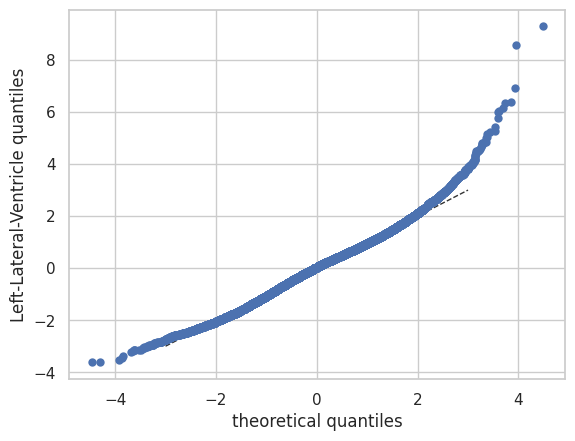

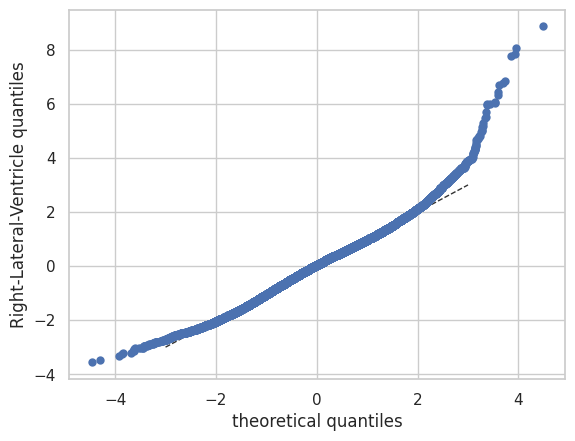

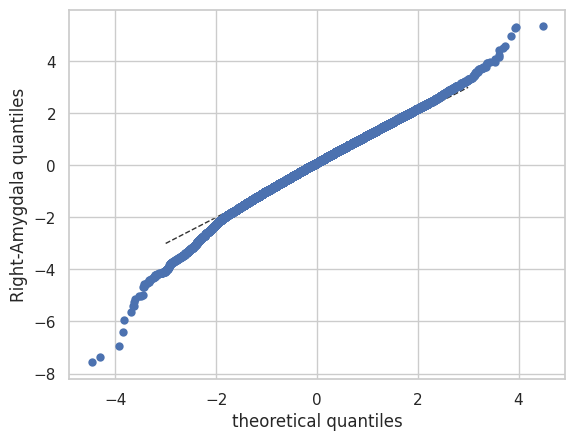

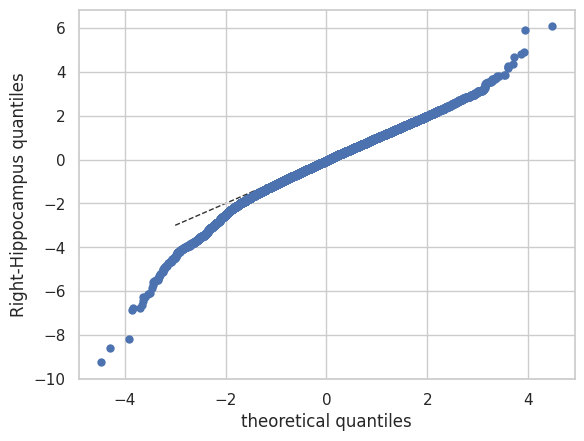

In [25]:
plot_qq(norm_test, plot_id_line=True)

In [48]:
norm_train.load_results("/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/CODE_new/PCNtoolkit/examples/resources/hbr_SHASH/save_dir_new/results/")

We can also split the QQ plots by batch effects:

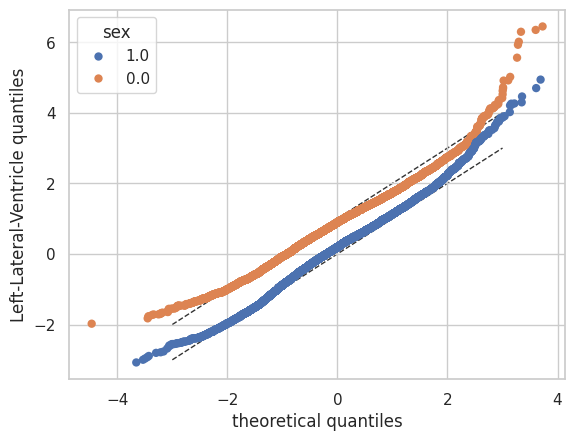

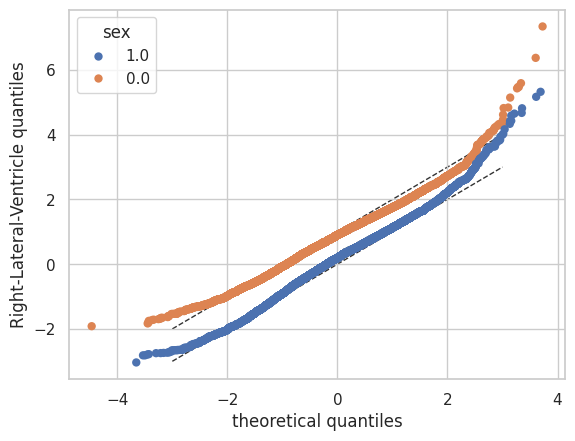

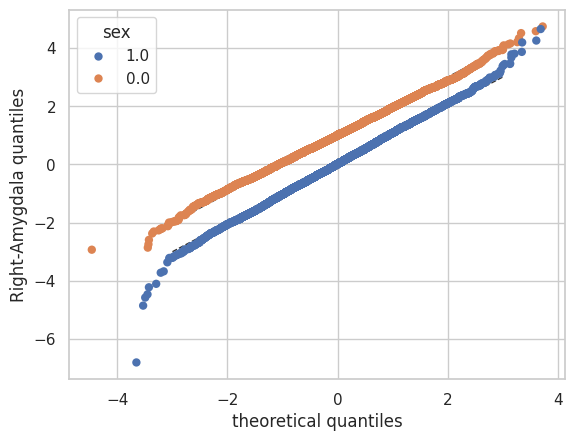

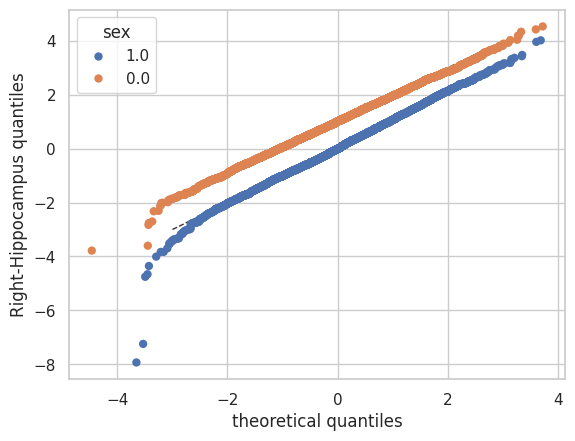

In [26]:
plot_qq(norm_train, plot_id_line=True, hue_data="sex", split_data="sex")
sns.set_theme(style="darkgrid", rc={"axes.facecolor": (0, 0, 0, 0)})

And finally the ridge plot:

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

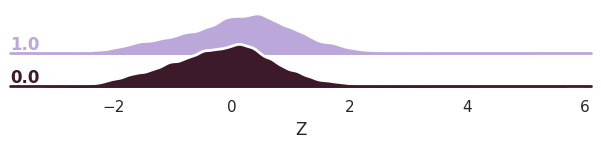

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

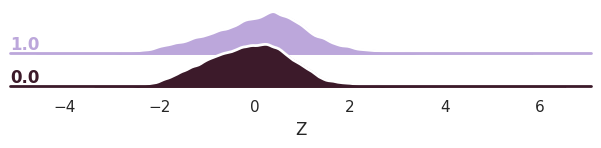

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

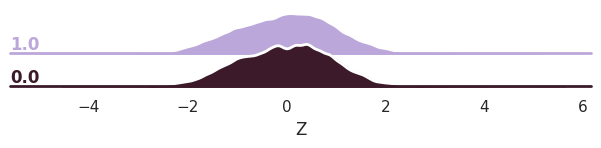

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

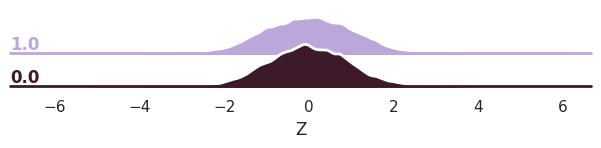

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

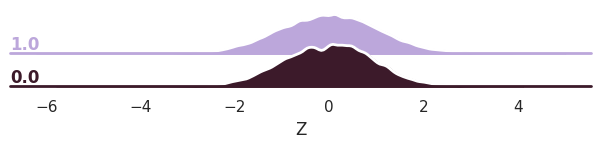

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

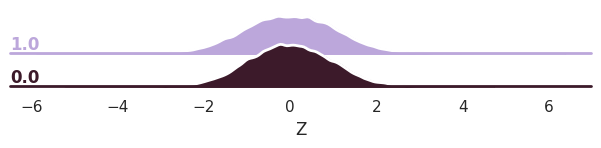

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

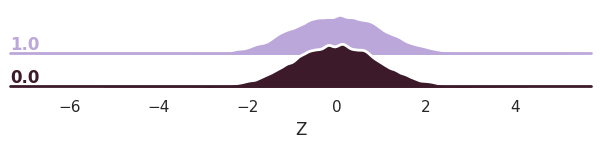

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

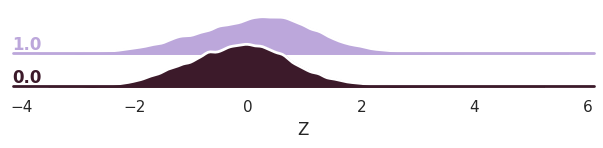

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

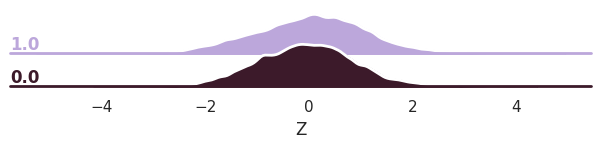

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

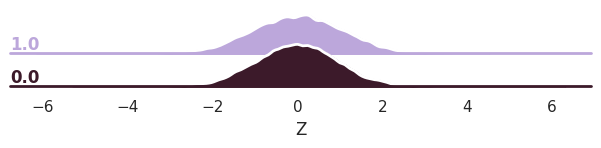

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

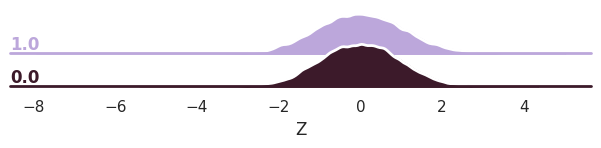

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

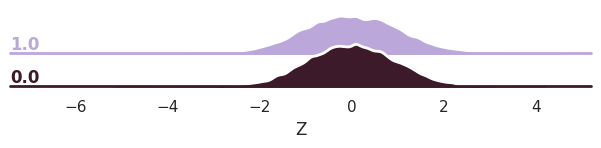

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

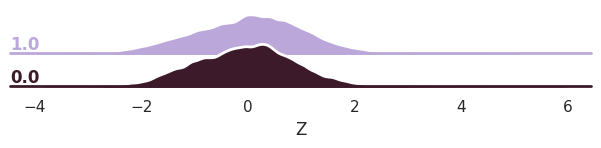

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

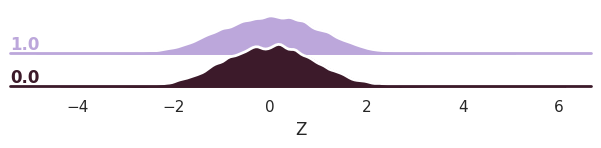

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

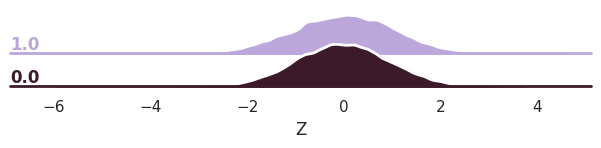

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

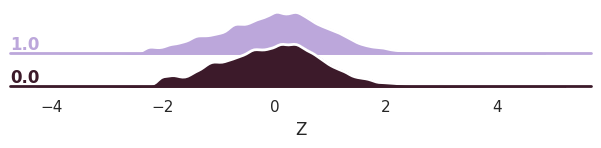

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

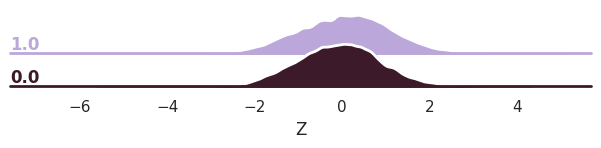

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

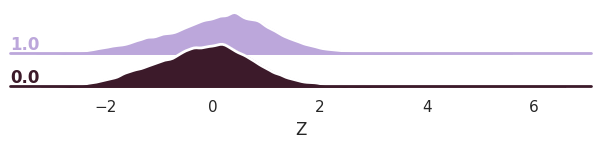

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

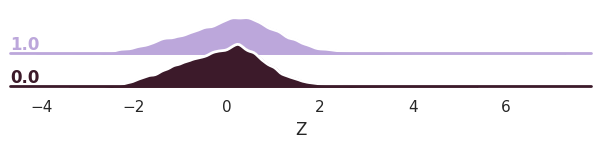

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

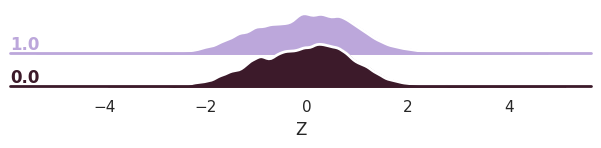

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

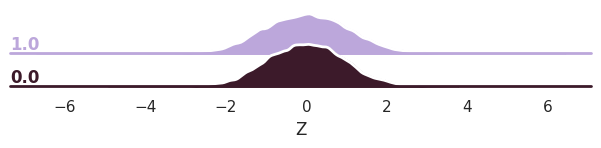

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

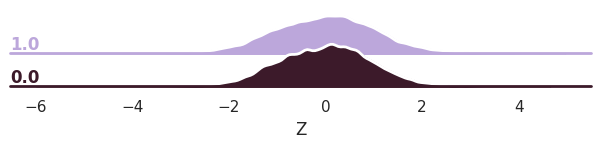

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

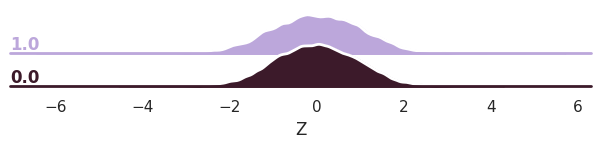

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

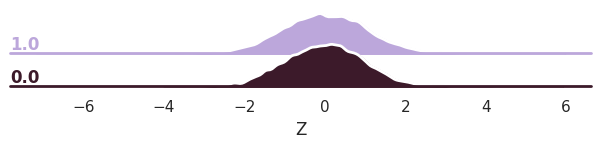

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

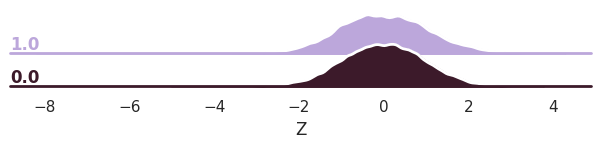

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

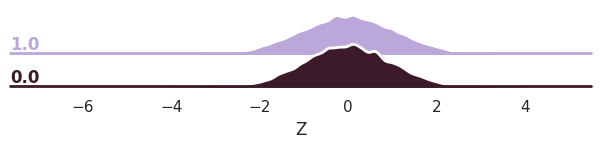

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

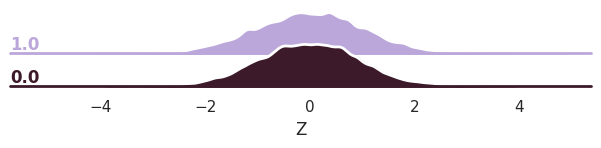

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

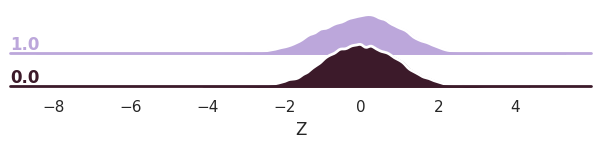

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

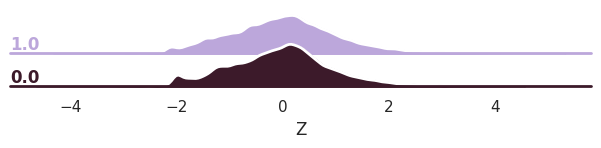

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

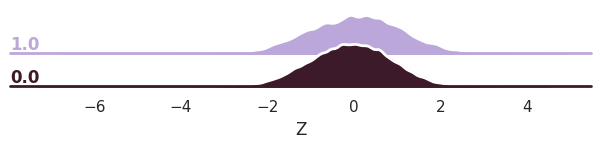

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

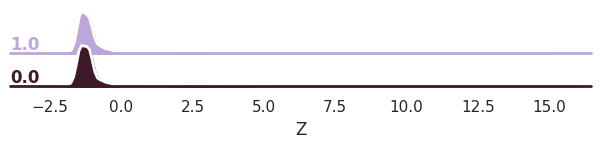

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

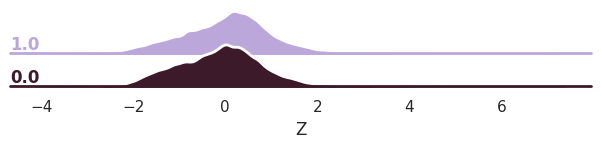

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

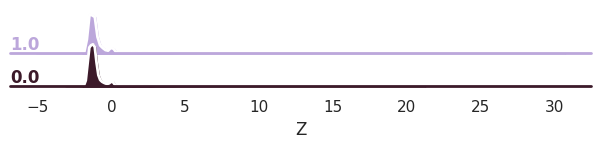

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

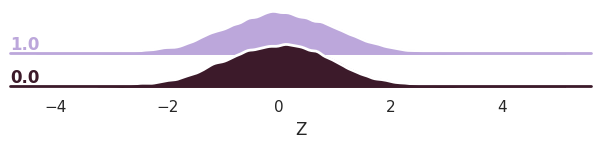

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

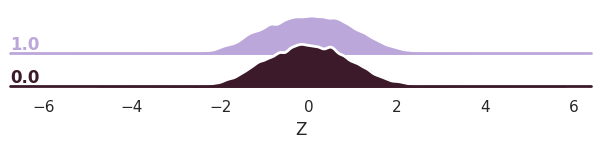

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

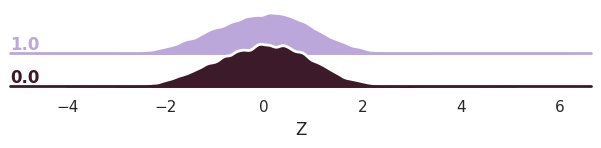

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

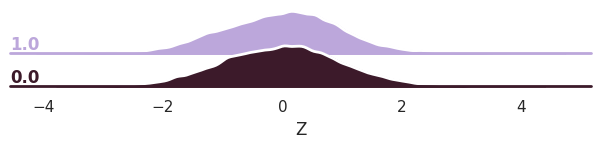

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

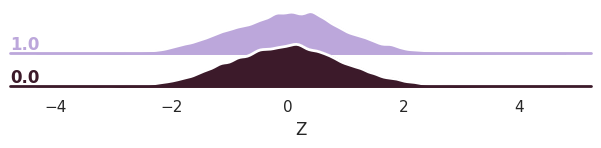

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

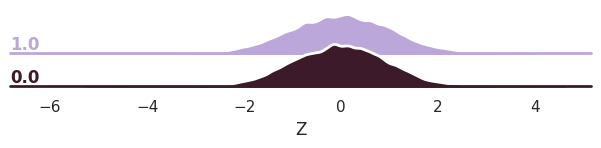

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

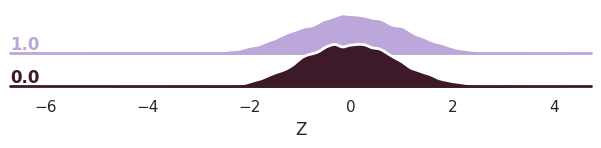

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

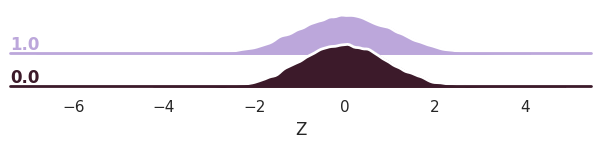

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

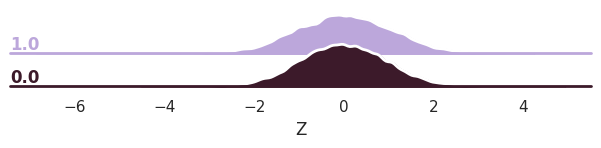

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

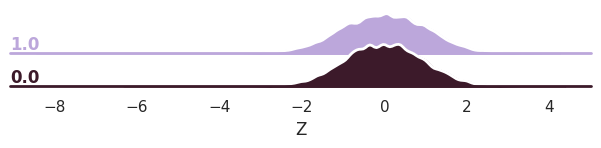

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

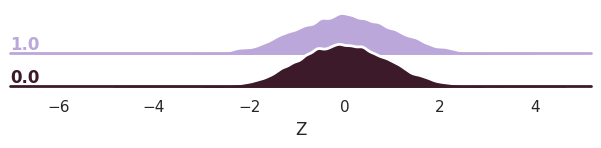

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

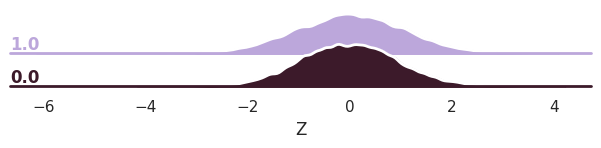

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

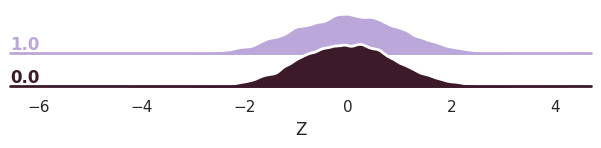

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

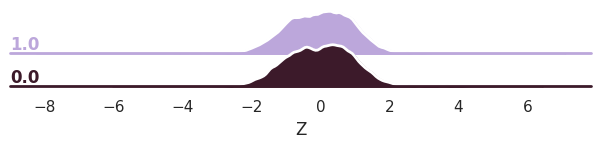

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

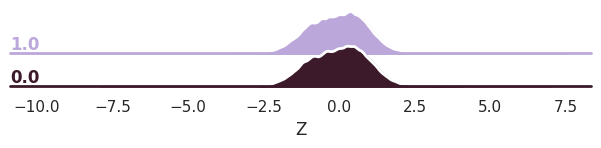

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

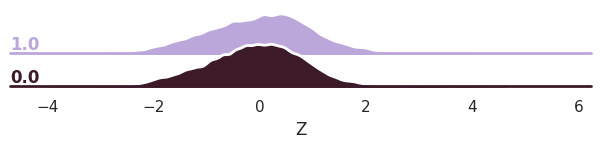

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

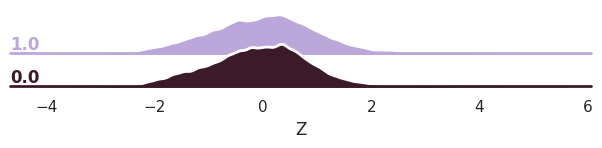

/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/preclineu/johbay/.conda/envs/py312/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to 

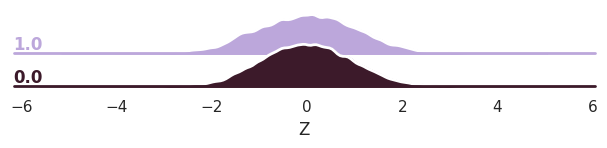

In [53]:
plot_ridge(
    norm_train, "Z", split_by="sex"
)  # We can also show the 'Y' variable, and that will show the marginal distribution of the response variable, per batch effect.

Evaluation statistcs are stored in the NormData object:

In [ ]:
display(train.get_statistics_df())
display(test.get_statistics_df())

## What's next?

Now we have a normative hierarchical Bayesian regression model, we can use it to:

- Make predictions on new data
- Harmonize data, this means that we 'remove' the batch effects from the data, by simulating what the data would have looked like if all data was from the same batch.
- Synthesize new data
- Extend the model using data from new batches

### Predicting

In [ ]:
model.predict(test)

### Harmonize

In [ ]:
# Harmonizing is also easy:
reference_batch_effect = {
    "site": "Beijing_Zang",
    "sex": "M",
}  # Set a pseudo-batch effect. I.e., this means 'pretend that all data was from this site and sex'

model.harmonize(test, reference_batch_effect=reference_batch_effect)  # <- easy

plt.style.use("seaborn-v0_8")
df = test.to_dataframe()
fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
sns.scatterplot(data=df, x=("X", "age"), y=("Y", feature_to_plot), hue=("batch_effects", "site"), ax=ax[0])
sns.scatterplot(data=df, x=("X", "age"), y=("Y_harmonized", feature_to_plot), hue=("batch_effects", "site"), ax=ax[1])
ax[0].title.set_text("Unharmonized")
ax[1].title.set_text("Harmonized")
ax[0].legend([], [])
ax[1].legend([], [])
ax[0].set_xlabel("Age")
ax[0].set_ylabel(feature_to_plot)
ax[1].set_xlabel("Age")
ax[1].set_ylabel(feature_to_plot)
plt.tight_layout()
plt.show()

### Synthesize

Our models can synthesize new data that follows the learned distribution. 

Not only the distribution of the response variables given a covariate is learned, but also the ranges of the covariates _within_ each batch effect. So if we have fitted a model on a number of sites, and subjects from A have an age between 10 and 20, then the synthesized pseudo-subjects from site A will also have an age between 10 and 20.

Not only that, but we also sample the batch effects in the frequency of the batch effects in the original data. So if the train data contained twice as many subjects from site A as site B, then the synthesized pseudo-subjects will also have twice as many subjects from site A as site B.

In [ ]:
# Generate 10000 synthetic datapoints from scratch
synthetic_data = model.synthesize(covariate_range_per_batch_effect=True, n_samples=1000)  # <- also easy
# Show the synthetic data along with the centiles
plot_centiles(
    model,
    covariate="age",  # Which covariate to plot on the x-axis
    scatter_data=synthetic_data,
    show_other_data=True,
    harmonize_data=True,
    show_legend=True,
)


In [ ]:
# Synthesize new Y data for existing X data
new_test_data = test.copy()

# Remove the Y data, this way we will synthesize new Y data for the existing X data
if hasattr(new_test_data, "Y"):
    del new_test_data["Y"]

synthetic = model.synthesize(new_test_data)  # <- will fill in the missing Y data

In [ ]:
plot_centiles(
    model,
    centiles=[0.05, 0.5, 0.95],  # Plot arbitrary centiles
    covariate="age",  # Which covariate to plot on the x-axis
    scatter_data=synthetic,  # Scatter the train data points
    batch_effects="all",  # You can set this to "all" to show all batch effects
    show_other_data=False,  # Show data points that do not match any batch effects
    show_centile_labels=True,
    harmonize_data=True,  # Set this to False to see the difference
    show_legend=False,  # Don't show the legend because it crowds the plot
)

## Next steps

Please see the other tutorials for more examples, and we also recommend you to read the documentation! As this toolkit is still in development, the documentation may not be up to date. If you find any issues, please let us know! 

Also, feel free to contact us on Github if you have any questions or suggestions.

Have fun modeling!

### Bonus content

Here is another model configuration using a SHASH likelihood, but this one also has a linear regression in epsilon and delta. If you have a feature that is heavily skewed and for which the skewness also changes with the covariates, this is the model for you:

In [ ]:
# Here's a model with a SHASHb likelihood, with a linear regression in all four parameters, so including epsilon and delta.
# This is a very flexible model, but it will also take a lot longer to run.
mu = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    intercept=make_prior(
        random=True,
        mu=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
        sigma=make_prior(dist_name="Gamma", dist_params=(3.0, 1.0)),
    ),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
sigma = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(0.0, 3.0),
)

epsilon = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)

delta = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(
        0.0,
        3.0,  # Scale for smoothness
        0.6,  # We need to provide a vertical shift as well, because the SHASH mapping goes a bit wild with low values for delta
    ),
)

shashb2_regression_model = HBR(
    name="template",
    cores=16,
    progressbar=True,
    draws=1500,
    tune=500,
    chains=4,
    nuts_sampler="nutpie",
    likelihood=SHASHbLikelihood(mu, sigma, epsilon, delta),
)